In [ ]:
import torch

### Gradient of a Scalar Function

A function  
$$
f : \mathbb{R}^n \rightarrow \mathbb{R}
$$
takes a vector as input and produces a scalar as output.

The **gradient** of $f$ is the derivative of this scalar with respect to the vector input.  
It is a vector of partial derivatives:

$$
\nabla f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

So, the gradient is simply the **rate of change of a scalar function with respect to a vector**, written as a vector.

In [ ]:
a = torch.tensor([1., 2., 3.])
b = torch.tensor([10., 20., 30.])
c = torch. tensor([100., 200., 300.])

In [ ]:
a.requires_grad
# requires_grad is a Boolean field for every tensor; Default it is set to False, i.e. tensor does not need the gradients

False

### Computing Gradients in PyTorch

We demonstrate gradient computation using two approaches:

1. **`torch.autograd.grad`**  
   Computes and returns the gradients explicitly.  
   It does **not** accumulate gradients in the `.grad` field of tensors unless done manually.

2. **`backward()`**  
   Computes gradients via backpropagation and **accumulates them in the `.grad` attribute**

Both methods rely on PyTorch’s automatic differentiation engine, but they are used in different scenarios depending on whether we need the gradients as returned values or stored in the computation graph.

In [ ]:
a.requires_grad = True
b.requires_grad = True

In [ ]:
# let's use autograd(o/p, i/p)

d = a.pow(2).sum() + b.log().sum()
torch.autograd.grad(d,(a,b))

(tensor([2., 4., 6.]), tensor([0.1000, 0.0500, 0.0333]))

In [ ]:
# let's use backward()

h = a.pow(2).sum() + b.log().sum()
print('Before Backpropagation')
print(a.grad)
print(b.grad)
h.backward()
print('Ater Backpropagation')
print(a.grad)
print(b.grad)

Before Backpropagation
None
None
Ater Backpropagation
tensor([2., 4., 6.])
tensor([0.1000, 0.0500, 0.0333])


In [ ]:
h.backward()
print('After Backpropagation twice')
print(a.grad)
print(b.grad)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

### Calling `backward()` Multiple Times

By default, PyTorch **frees the computation graph after a backward pass** to save memory.  
Because of this, calling `backward()` again on the same graph raises an error.

We can handle this in **two ways**:

#### 1. Retain the computation graph
Keep the graph during the first backward pass:
```python
loss.backward(retain_graph=True)
loss.backward()
```

#### 2. Recompute the forward pass and call `backward()` again
Run the forward computation again to create a new computation graph, then backpropagate


In [ ]:
h = a.pow(2).sum() + b.log().sum()
print('Before BackPropagation')
print(a.grad)
print(b.grad)
h.backward(retain_graph=True)
print('After BackPropagation')
print(a.grad)
print(b.grad)
h.backward()
print('Before BackPropagation (2nd Time)')
print(a.grad)
print(b.grad)

Before BackPropagation
tensor([2., 4., 6.])
tensor([0.1000, 0.0500, 0.0333])
After BackPropagation
tensor([ 4.,  8., 12.])
tensor([0.2000, 0.1000, 0.0667])
Before BackPropagation (2nd Time)
tensor([ 6., 12., 18.])
tensor([0.3000, 0.1500, 0.1000])


In [ ]:
h = a.sum() + b.log().sum()
h.backward()
print('After BackPropagation (3rd Time)')
print(a.grad)
print(b.grad)

h = a.sum() + b.log().sum()
h.backward()
print('Before BackPropagation (4th Time)')
print(a.grad)
print(b.grad)

After BackPropagation (3rd Time)
tensor([ 7., 13., 19.])
tensor([0.4000, 0.2000, 0.1333])
Before BackPropagation (4th Time)
tensor([ 8., 14., 20.])
tensor([0.5000, 0.2500, 0.1667])


### Take Away

`backward()` does **not overwrite** gradients → it **adds** to `.grad`.

### When to use `torch.autograd.grad()` instead of `backward()`?

Both methods compute gradients using PyTorch autograd, but `torch.autograd.grad()` provides more flexibility and control.

#### 1. Does not accumulate gradients in `.grad`
`backward()` → stores gradients in the `.grad` field (and accumulates them)  
`autograd.grad()` → **returns the gradients directly** without modifying `.grad`

This avoids the need to manually zero gradients.

#### 2. Compute gradients for specific tensors only
With `autograd.grad()` we explicitly specify:
```python
torch.autograd.grad(outputs=loss, inputs=[x, y])

### Gradient-based Optimization using `torch.autograd.grad`

In this example, we minimize the loss:
$$
l = (a - 1)^2 + (b + 1)^2 + (a - b)^2
$$

At each iteration:
1. We compute the loss.
2. We obtain the gradients using:
   ```python
   ga, gb = torch.autograd.grad(l, (a, b))

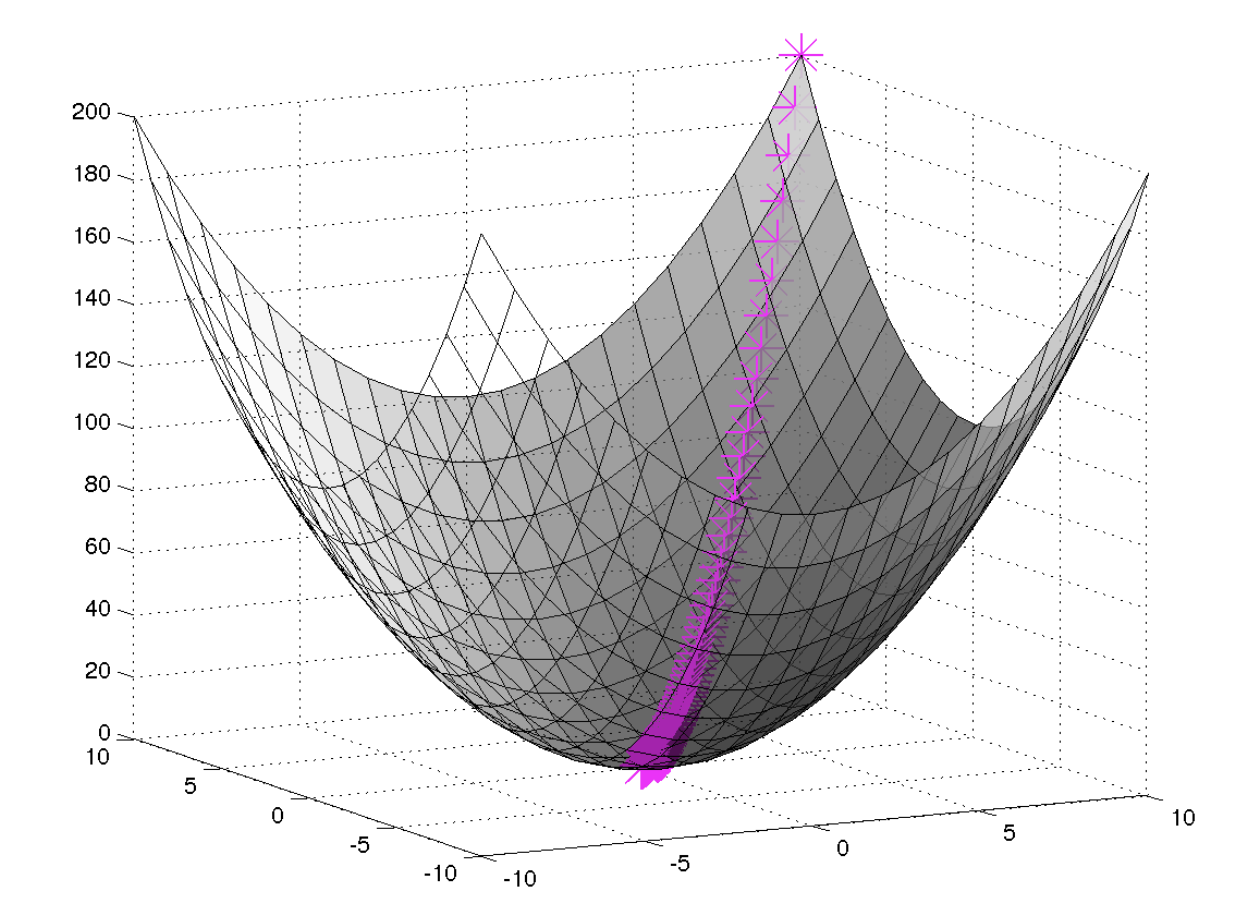

In [ ]:
# Sample module that uses autograd and GD

a = torch.tensor( 1.0).requires_grad_()
b = torch.tensor(-1.).requires_grad_()

eta = 0.1

for k in range(20):
  l = (a - 1.0)**2 + (b + 1.0)**2 + (a - b)**2
  ga, gb = torch.autograd.grad(l, (a, b)) # ga = 2(a-1) + 2(a-b), gb = 2(b + 1) - 2(a - b)
  with torch.no_grad():
    a -= eta * ga
    b -= eta * gb
  print('iteration %d: loss = %.4f \t a = %.3f \t b = %.3f, '%(k,l.item(),a.item(), b.item()))

iteration 0: loss = 4.0000 	 a = 0.600 	 b = -0.600, 
iteration 1: loss = 1.7600 	 a = 0.440 	 b = -0.440, 
iteration 2: loss = 1.4016 	 a = 0.376 	 b = -0.376, 
iteration 3: loss = 1.3443 	 a = 0.350 	 b = -0.350, 
iteration 4: loss = 1.3351 	 a = 0.340 	 b = -0.340, 
iteration 5: loss = 1.3336 	 a = 0.336 	 b = -0.336, 
iteration 6: loss = 1.3334 	 a = 0.334 	 b = -0.334, 
iteration 7: loss = 1.3333 	 a = 0.334 	 b = -0.334, 
iteration 8: loss = 1.3333 	 a = 0.334 	 b = -0.334, 
iteration 9: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 10: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 11: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 12: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 13: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 14: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 15: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 16: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 17: loss = 1.3333 	 a = 0.333 	 b = -0.333, 
iteration 18: loss =

**Putting it all together**
Let's train an MLP on MNIST dataset

In [ ]:
# Import the necessary
from torchvision import datasets
import torchvision.transforms as transforms

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# number of subprocesses to use for data loading
num_workers = 1

# how many samples per batch to load
batch_size = 50

# percentage of training set to use as validation
valid_size = 0.2

# convert data to torch.FloatTensor
transform = transforms.ToTensor()

# choose the training and testing datasets
train_data = datasets.MNIST(root = 'data', train = True, download = True, transform = transform)
test_data = datasets.MNIST(root = 'data', train = False, download = True, transform = transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_index, valid_index = indices[split:], indices[:split]

# prepare data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size = batch_size, num_workers = num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size = batch_size, sampler = torch.utils.data.SubsetRandomSampler(valid_index), num_workers = num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size = batch_size, num_workers = num_workers)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


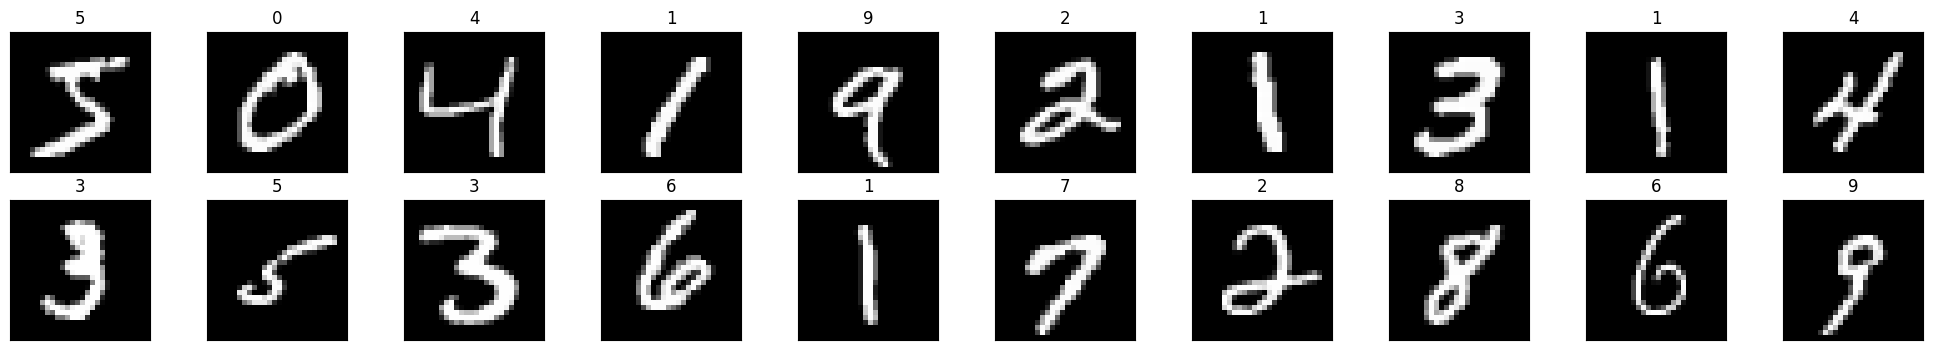

In [ ]:
#visualize data

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    # print out the correct label for each image
    # .item() gets the value contained in a Tensor
    ax.set_title(str(labels[idx].item()))

**Basic MLP Structure**

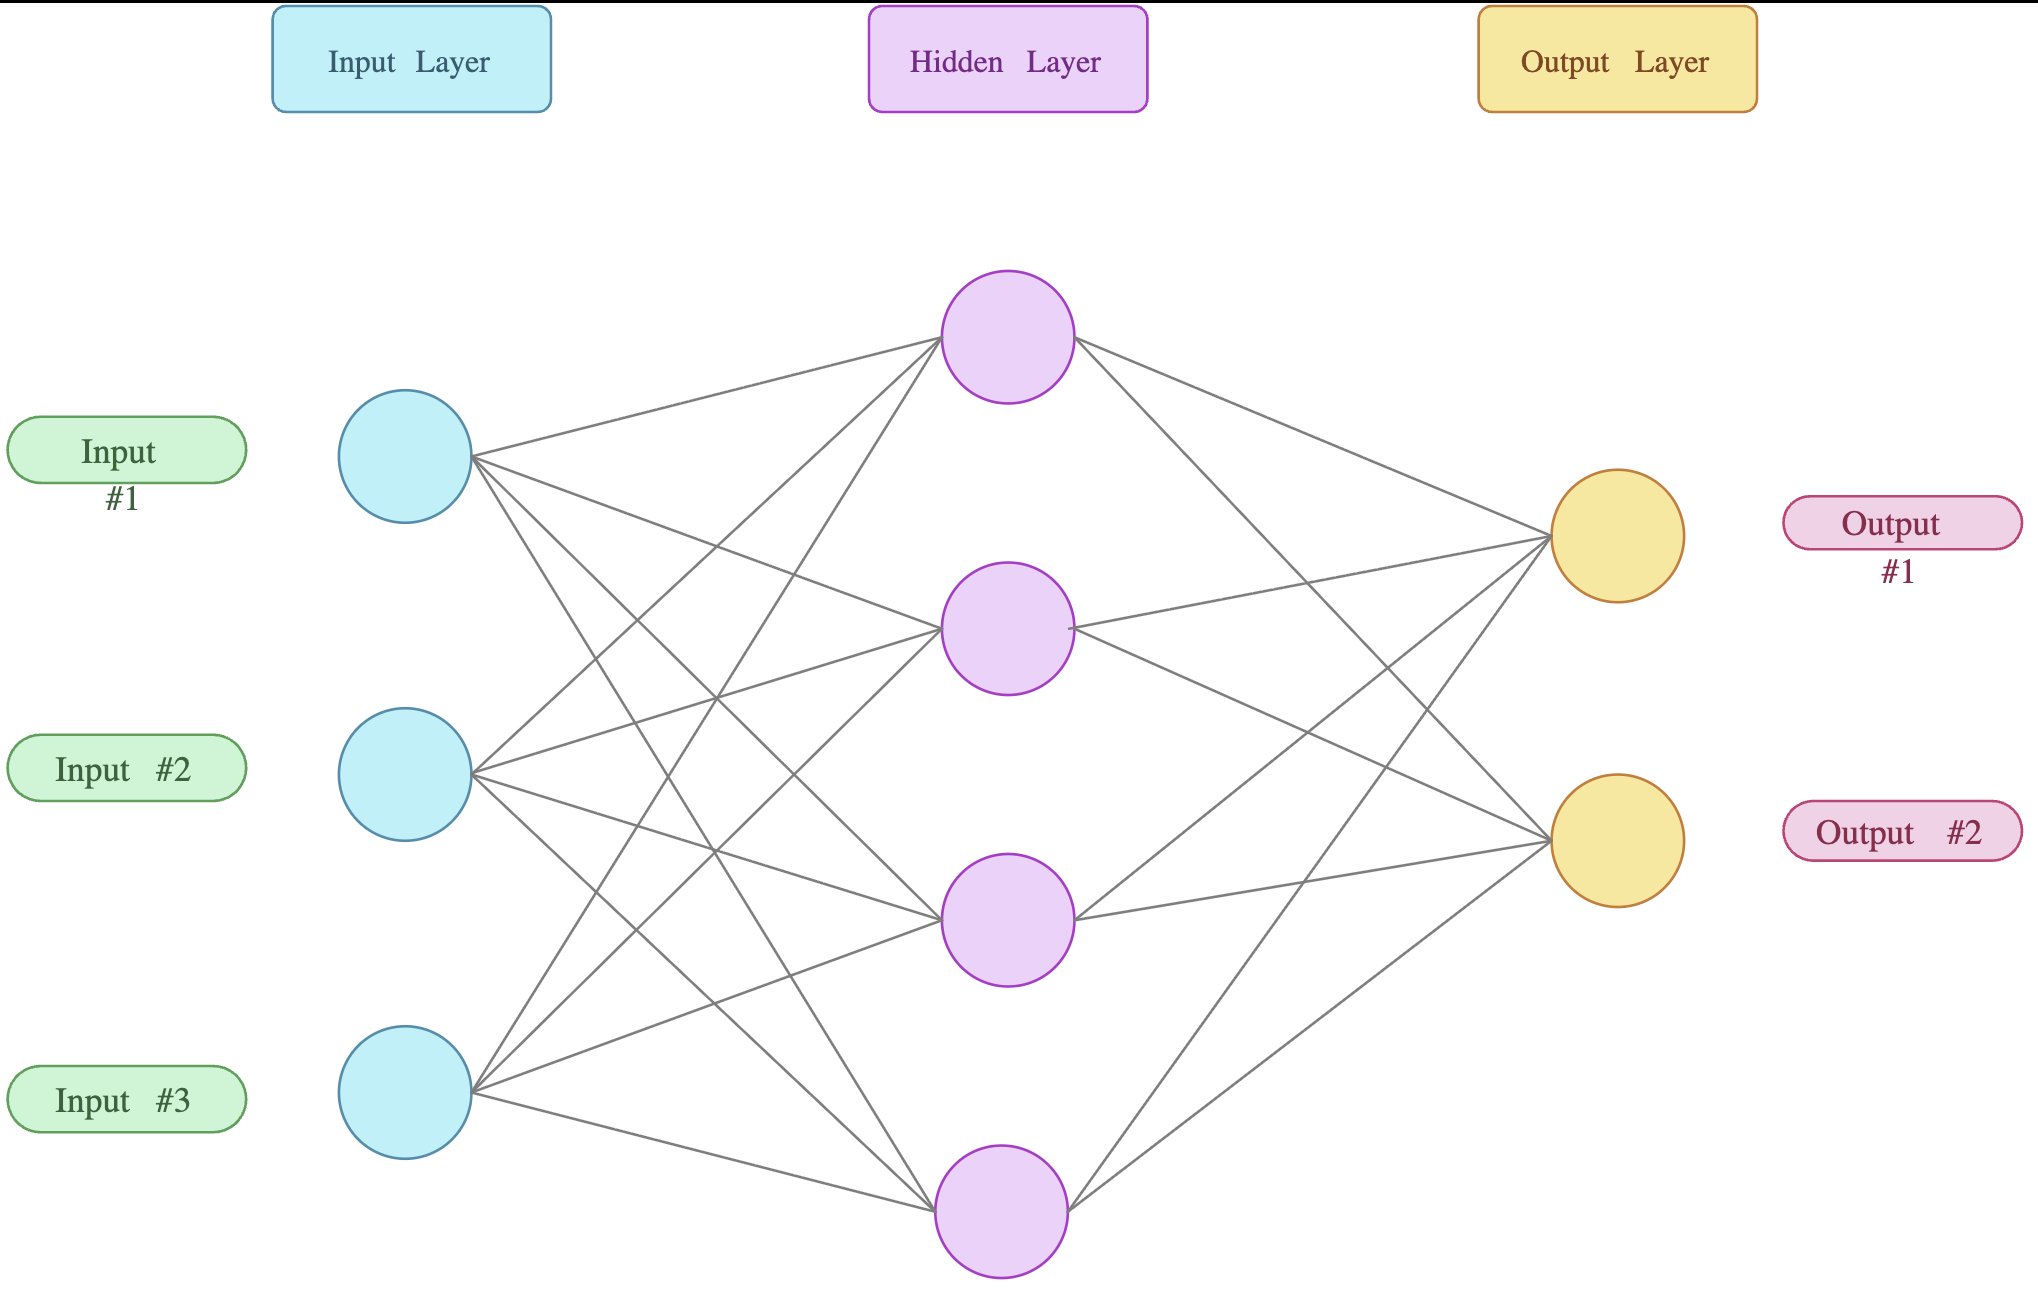

In [ ]:
# define the model (MLP) architecture
import torch.nn as nn
import torch.nn.functional as F

# define NN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()

        # linear layer (784 -> n_hidden1)
        self.fc1 = nn.Linear(28*28, 512)

        # linear layer (n_hidden1 -> n_hidden)
        self.fc2 = nn.Linear(512,512)

        # linear layer (n_hidden -> 10)
        self.fc3 = nn.Linear(512,10)


    def forward(self,x):
        # flatten image input
        x = x.view(-1,28*28)

        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))

        # add hidden layer, with relu activation function
        x = F.relu(self.fc2(x))

        # add output layer
        x = self.fc3(x)
        return x


# initialize the NN
model = Net()
print(model)

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
)


In [ ]:
# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer (stochastic gradient descent) and learning rate = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)

In [ ]:
from tqdm import tqdm

# number of epochs to train the model
n_epochs = 10

# initialize tracker for minimum validation loss
valid_loss_min = np.inf
# set initial "min" to infinity

for epoch in range(n_epochs):
    # monitor losses
    train_loss = 0
    valid_loss = 0

    ###################
    # training the model #
    ###################
    model.train() # prep model for training

    for data,label in tqdm(train_loader): # (0.8*50000)/50
        # clear the gradients of all the variables
        optimizer.zero_grad()

        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)

        # calculate the loss
        loss = criterion(output,label)

        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # perform a single optimization step (parameter update)
        optimizer.step()

        # update running training loss
        train_loss += loss.item()* data.size(0)


    ######################
    # validate the model #
    ######################
    model.eval()  # prep model for evaluation

    for data,label in tqdm(valid_loader): # (0.2*50000)/50

        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)

        # calculate the loss
        loss = criterion(output,label)

        # update running validation loss
        valid_loss += loss.item() * data.size(0)

    # print training/validation statistics
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1,
        train_loss,
        valid_loss
        ))

    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

100%|██████████| 240/240 [00:02<00:00, 108.81it/s]


Epoch: 1 	Training Loss: 1.357651 	Validation Loss: 0.539578
Validation loss decreased (inf --> 0.539578).  Saving model ...


100%|██████████| 240/240 [00:02<00:00, 104.54it/s]


Epoch: 2 	Training Loss: 0.429536 	Validation Loss: 0.362083
Validation loss decreased (0.539578 --> 0.362083).  Saving model ...


100%|██████████| 240/240 [00:02<00:00, 118.70it/s]


...

Epoch: 8 	Training Loss: 0.211479 	Validation Loss: 0.203673
Validation loss decreased (0.219828 --> 0.203673).  Saving model ...


100%|██████████| 240/240 [00:02<00:00, 117.16it/s]


Epoch: 9 	Training Loss: 0.196131 	Validation Loss: 0.189359
Validation loss decreased (0.203673 --> 0.189359).  Saving model ...


100%|██████████| 240/240 [00:02<00:00, 100.75it/s]

Epoch: 10 	Training Loss: 0.182497 	Validation Loss: 0.176475
Validation loss decreased (0.189359 --> 0.176475).  Saving model ...


In [ ]:
    ##################
    # test the model #
    ##################

# Load the best model
model.load_state_dict(torch.load('model.pt'))
model.eval()  # Set the model to evaluation mode

# Initialize variables to track test loss and accuracy
test_loss = 0.0
correct = 0
total = 0

# Testing the model
for data, labels in test_loader:
  output = model(data)

  loss = criterion(output, labels)
  test_loss += loss.item() * data.size(0)

  _, preds = torch.max(output, 1)
  # Update correct predictions count
  correct += (preds == labels).sum().item()
  total += labels.size(0)

# Calculate average loss and accuracy
test_loss = test_loss / total
accuracy = correct / total * 100

# Print test results
print(f'Test Loss: {test_loss:.6f}')
print(f'Test Accuracy: {accuracy:.2f}%')


Test Loss: 0.179045
Test Accuracy: 94.77%


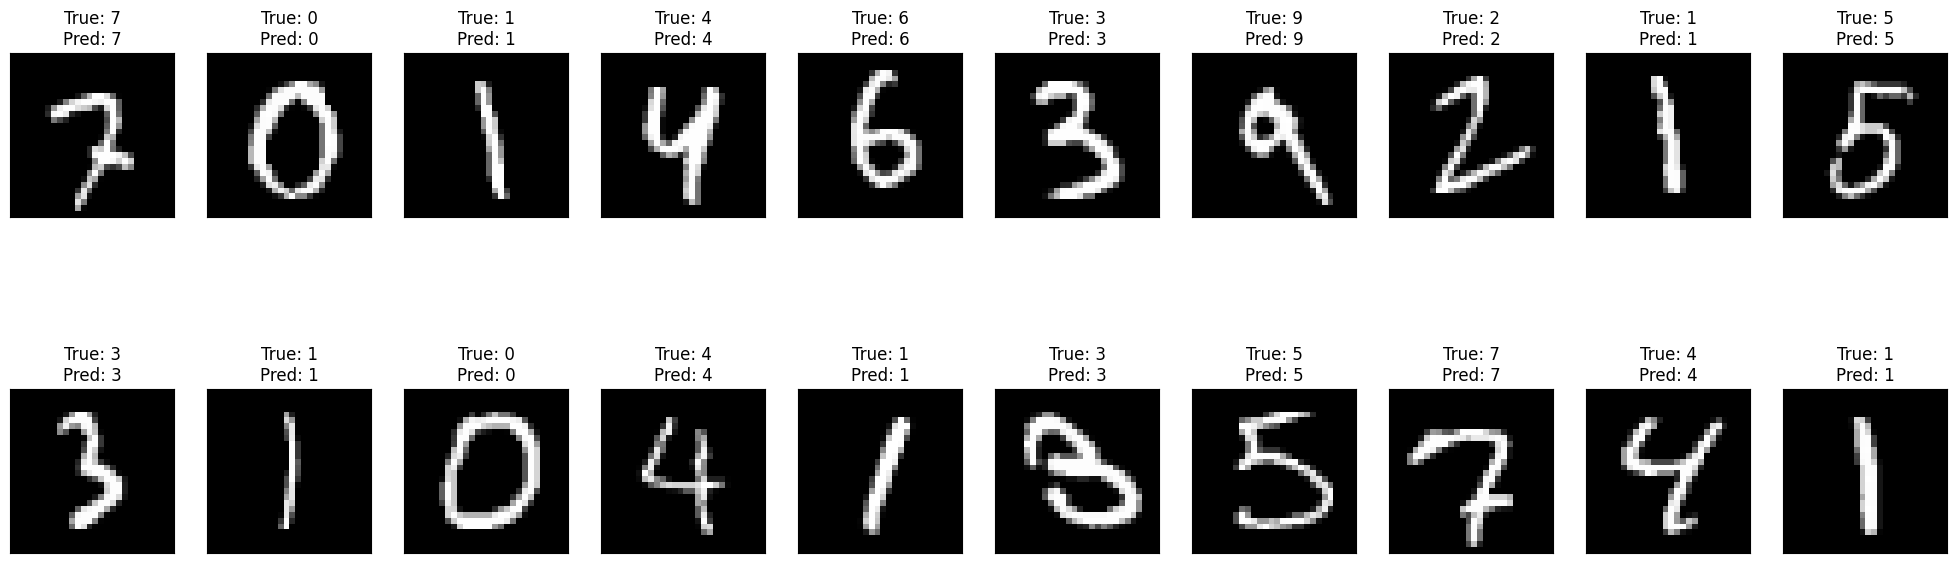

In [ ]:
import random

# Get one batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

random_indices = random.sample(range(len(images)), 20)

fig = plt.figure(figsize=(25, 8))
for idx, random_idx in enumerate(random_indices):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    img = images[random_idx].numpy().squeeze()  # Convert to NumPy and squeeze dimensions
    ax.imshow(img, cmap='gray')

    # Get the true label and predicted label
    true_label = labels[random_idx].item()
    output = model(images[random_idx].unsqueeze(0))  # Add batch dimension for prediction
    _, predicted_label = torch.max(output, 1)

    ax.set_title(f"True: {true_label}\nPred: {predicted_label.item()}")
